In [ ]:

import os
import glob
import pandas as pd
import numpy as np
import nibabel as nib
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.ndimage import zoom
from tensorflow.keras import layers, models
from nilearn import plotting
import matplotlib.pyplot as plt  


In [2]:
# Set working directory
data_dir = 'ds002424'

# Find and print num of fMRI files found
all_fmri_files = glob.glob('ds002424/sub-*/ses-T1/func/*.nii.gz')
print(f"Found {len(all_fmri_files)} fmri files.")

# Load participants file
labels_df = pd.read_csv('ds002424/phenotype/participants.tsv', sep='\t')
labels_df = labels_df[['participant_id', 'ADHD_diagnosis']]  # diagnosis: ADHD or Control

# Another way to print all fmri file
# fmri_files = glob.glob('ds002424/**/func/*.nii.gz', recursive=True)
# print(f" Found {len(fmri_files)} fMRI files.")
# for f in fmri_files[:5]:  # show the first few
#     print(f)


Found 546 fmri files.


In [3]:
# Create a dictionary mapping participant_id -> label
label_dict = dict(zip(labels_df['participant_id'], labels_df['ADHD_diagnosis']))

# print(label_dict)  # just to check

# Function to extract participant ID from a filename
def extract_participant_id(filename):
    base = os.path.basename(filename)
    participant_id = base.split('_')[0]  
    return participant_id

# Align labels with files
aligned_labels = []
aligned_files = []

for fpath in all_fmri_files:
    pid = extract_participant_id(fpath)
    if pid in label_dict:
        aligned_files.append(fpath)
        aligned_labels.append(label_dict[pid])
    else:
        print(f"Warning: participant ID {pid} not found in labels. Skipping file.")

# Convert to numpy arrays
aligned_labels = np.array(aligned_labels)
print(f"Number of files after alignment: {len(aligned_files)}")
print(f"Labels array shape: {aligned_labels.shape}")

# print(aligned_files, aligned_labels)



Number of files after alignment: 546
Labels array shape: (546,)


Shape of fMRI data: (128, 120, 32, 139)
Total volumes (timepoints): 139
Maximum volume index: 138


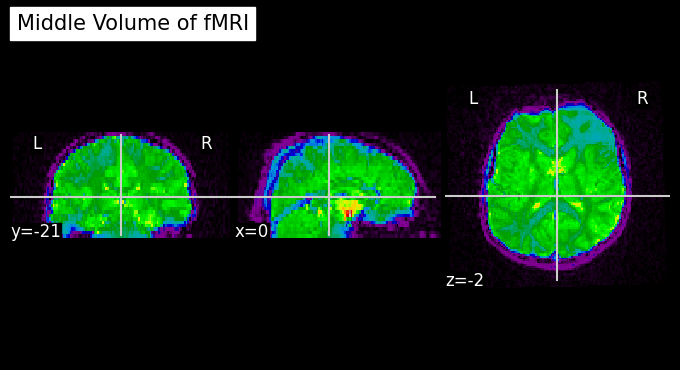

In [4]:
# --- Plot fMRI data example ---

from nilearn import plotting

# Load a single fMRI file
fmri_file = 'ds002424/sub-06/ses-T1/func/sub-06_ses-T1_task-SLD_bold.nii.gz'
img = nib.load(fmri_file)

# Get fMRI shape
data = img.get_fdata()
print("Shape of fMRI data:", data.shape)

# Find the max timepoint
n_timepoints = img.shape[-1]
print(f"Total volumes (timepoints): {n_timepoints}")
print(f"Maximum volume index: {n_timepoints - 1}")

# Displays and plot the middle volume
middle_volume = img.slicer[..., img.shape[-1] // 2]
plotting.plot_epi(middle_volume, title="Middle Volume of fMRI")
plotting.show()

# Function to display a custom volume
def show_volume(volume_idx):
    vol = img.get_fdata()[..., volume_idx]
    plt.imshow(np.rot90(vol[:, :, vol.shape[2] // 2]), cmap='gray')
    plt.title(f'Volume {volume_idx}')
    plt.axis('off')
    plt.show()

# Example: display volume 20
show_volume(120)
show_volume(20)



In [5]:
# --- SPLIT DATA ---
X_train, X_test, y_train, y_test = train_test_split(
    aligned_files, aligned_labels, 
    test_size=0.05, 
    random_state=42, 
    stratify=aligned_labels
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))


Training samples: 518
Test samples: 28


In [6]:
# --- PREPROCESSING FUNCTION ---
def preprocess_fmri(file_path, target_shape=(128, 120, 32)):
    try:
        img = nib.load(file_path)
        data = img.get_fdata()  
        
        # 1) Extract mean volume over time
        mean_vol = np.mean(data, axis=-1)
        
        # 2) Normalize (z-score across all voxels)
        mean_vol = (mean_vol - mean_vol.mean()) / (mean_vol.std() + 1e-8)  
        
        # 3) Resize volume to target shape
        factors = [t / s for t, s in zip(target_shape, mean_vol.shape)]
        resized_vol = zoom(mean_vol, factors, order=1)  
        
        # 4) Add channel dimension for CNN
        resized_vol = np.expand_dims(resized_vol, axis=-1)  
        
        return resized_vol.astype(np.float32)
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None



In [7]:
# --- PREPROCESS DATA ---
def preprocess_dataset(file_paths, labels):
    X = []
    y_clean = []
    for fpath, label in zip(file_paths, labels):
        processed = preprocess_fmri(fpath)
        if processed is not None:
            X.append(processed)
            y_clean.append(label)
    return np.array(X), np.array(y_clean)

print("Preprocessing training set...")
X_train, y_train = preprocess_dataset(X_train, y_train)

print("Preprocessing test set...")
X_test, y_test = preprocess_dataset(X_test, y_test)

Preprocessing training set...
Preprocessing test set...


In [12]:
# --- Build 3D CNN model ---
def build_cnn_model(input_shape=(128, 120, 32, 1), dropout_rate=0.3):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        
        layers.Conv3D(16, kernel_size=(3, 3, 3), activation='relu', padding='same'),
        layers.MaxPooling3D(pool_size=(2, 2, 2)),
        
        layers.Conv3D(32, kernel_size=(3, 3, 3), activation='relu', padding='same'),
        layers.MaxPooling3D(pool_size=(2, 2, 2)),
        
        layers.Conv3D(64, kernel_size=(3, 3, 3), activation='relu', padding='same'),
        layers.MaxPooling3D(pool_size=(2, 2, 2)),
        
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(1, activation='sigmoid')
    ])

    
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Build and summarize model
model = build_cnn_model(X_train.shape[1:])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv3d_5 (Conv3D)                    │ (None, 128, 120, 32, 16)    │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling3d_5 (MaxPooling3D)       │ (None, 64, 60, 16, 16)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_6 (Conv3D)                    │ (None, 64, 60, 16, 32)      │          13,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling3d_6 (MaxPooling3D)       │ (None, 32, 30, 8, 32)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_7 (Conv3D)                    │ (None, 32, 30, 8, 64)       │          55,360 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling3d_7 (MaxPooling3D)       │ (None, 16, 15, 4, 64)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 61440)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │       7,864,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,934,241 (30.27 MB)

 Trainable params: 7,934,241 (30.27 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 29s 425ms/step - accuracy: 0.4869 - loss: 1.1720 - val_accuracy: 0.5714 - val_loss: 0.6785
Epoch 2/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 29s 440ms/step - accuracy: 0.5312 - loss: 0.6903 - val_accuracy: 0.5714 - val_loss: 0.6824
Epoch 3/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 29s 441ms/step - accuracy: 0.5515 - loss: 0.6826 - val_accuracy: 0.5714 - val_loss: 0.6696
Epoch 4/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 28s 437ms/step - accuracy: 0.6200 - loss: 0.6635 - val_accuracy: 0.6071 - val_loss: 0.5955
Epoch 5/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 28s 435ms/step - accuracy: 0.6421 - loss: 0.6288 - val_accuracy: 0.7857 - val_loss: 0.5431
Epoch 6/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 29s 439ms/step - accuracy: 0.7609 - loss: 0.5241 - val_accuracy: 0.8214 - val_loss: 0.5414
Epoch 7/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 29s 442ms/step - accuracy: 0.7518 - loss: 0.4770 - val_accuracy: 0.8571 - val_loss: 0.3747
Epoch 8/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 28s 423ms/step - accuracy: 0.9172 - loss: 0.2512 - val_accu

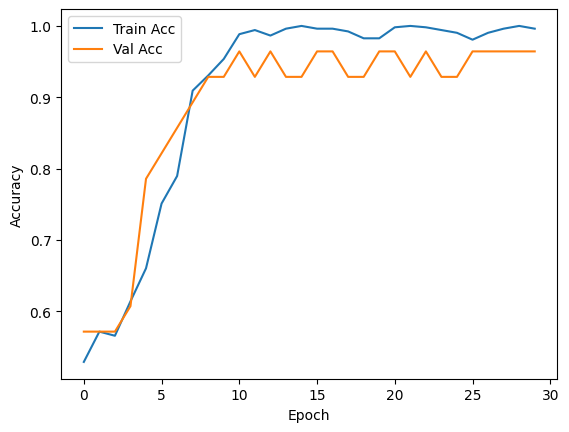

In [13]:
# --- Train ---
history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=30,
                    batch_size=8)

# --- Evaluate ---
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.3f}")

# --- Plot training curves ---
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [14]:
# Evaluate performance
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {test_acc:.2f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.9643 - loss: 0.0935
Test Accuracy: 0.96


In [15]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = (model.predict(X_test) > 0.5).astype("int32")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step
[[15  1]
 [ 0 12]]
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        16
           1       0.92      1.00      0.96        12

    accuracy                           0.96        28
   macro avg       0.96      0.97      0.96        28
weighted avg       0.97      0.96      0.96        28



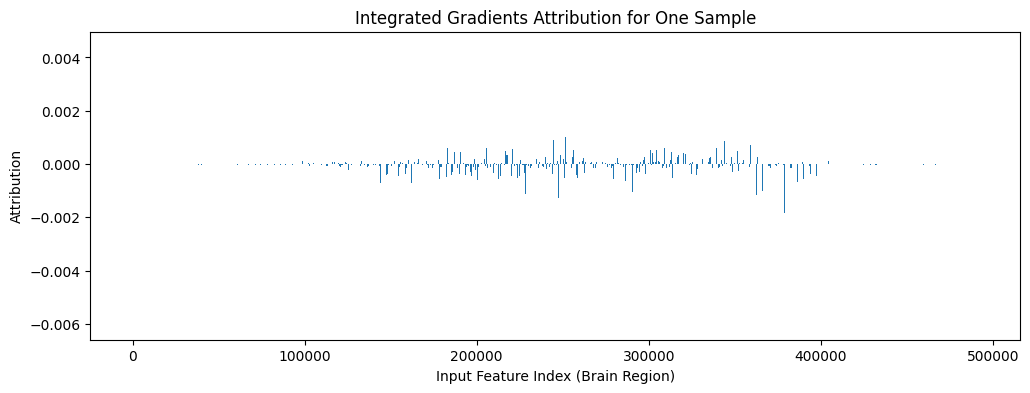

In [19]:
# Integrated Gradient

# --- Integrated Gradients Functions ---
def interpolate_inputs(baseline, input, steps=50):
    """Generates interpolated inputs between baseline and input."""
    alphas = np.linspace(0, 1, steps).reshape(-1, 1, 1, 1, 1)  # shape (50,1,1,1,1)
    delta = input - baseline
    interpolated = baseline + alphas * delta  # shape (50,128,120,32,1)
    return interpolated.astype(np.float32)


def compute_gradients(model, inputs, target_index=0):
    """Computes gradients of the output w.r.t the inputs."""
    inputs = tf.convert_to_tensor(inputs)
    with tf.GradientTape() as tape:
        tape.watch(inputs)
        predictions = model(inputs)
        output = predictions[:, target_index]
    grads = tape.gradient(output, inputs)
    return grads

def integrated_gradients(model, input, baseline=None, steps=50):
    """Calculates integrated gradients for a single input."""
    if baseline is None:
        baseline = np.zeros_like(input)
    
    interpolated_inputs = interpolate_inputs(baseline, input, steps)
    grads = compute_gradients(model, interpolated_inputs)
    avg_grads = tf.reduce_mean(grads, axis=0).numpy()
    integrated_grads = (input - baseline) * avg_grads
    return integrated_grads

# --- Select a sample from your test set ---
sample_index = 0
input_sample = X_test[sample_index:sample_index + 1].astype(np.float32)
baseline_sample = np.zeros_like(input_sample)

# --- Compute Integrated Gradients ---
ig_attributions = integrated_gradients(model, input_sample, baseline_sample, steps=50)

# --- Plotting Attributions ---
plt.figure(figsize=(12, 4))
ig_flat = ig_attributions.flatten()
plt.bar(range(len(ig_flat)), ig_flat)
plt.xlabel("Input Feature Index (Brain Region)")
plt.ylabel("Attribution")
plt.title("Integrated Gradients Attribution for One Sample")
plt.show()


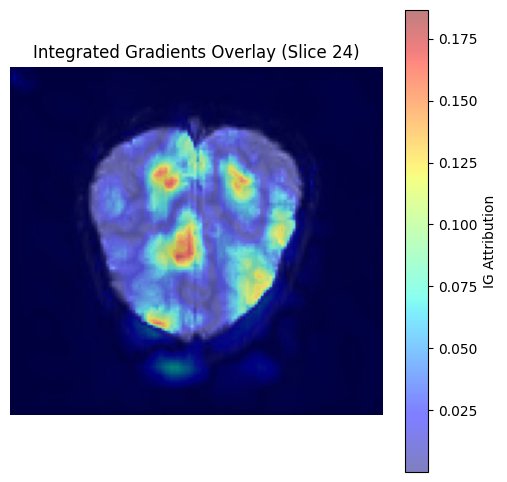

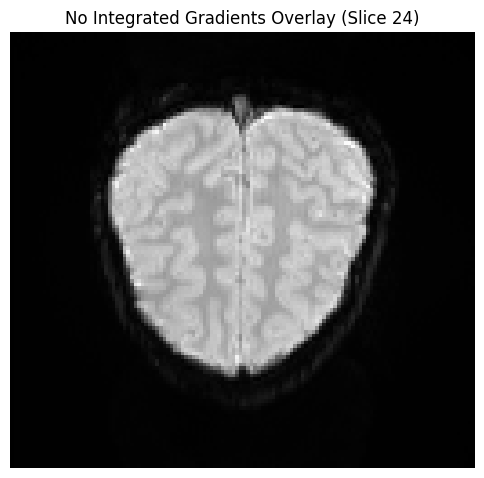

In [41]:
import numpy as np
import matplotlib.pyplot as plt
# --- Show IG ---
# Remove channel dimension & normalize
ig_map = np.squeeze(ig_attributions)   # (128,120,32)
ig_map = np.abs(ig_map)                # focus on magnitude
ig_map = ig_map / np.max(ig_map)       # normalize 0-1

# Select a slice 
slice_idx = 24
mri_slice = np.squeeze(input_sample[0, :, :, slice_idx, 0])   
ig_slice = ig_map[:, :, slice_idx]                           

# Plot overlay
plt.figure(figsize=(6,6))
plt.imshow(mri_slice.T, cmap='gray', origin='lower')          # MRI slice
plt.imshow(ig_slice.T, cmap='jet', alpha=0.5, origin='lower') # IG heatmap
plt.colorbar(label="IG Attribution")
plt.title(f"Integrated Gradients Overlay (Slice {slice_idx})")
plt.axis('off')
plt.show()

plt.figure(figsize=(6,6))
plt.imshow(mri_slice.T, cmap='gray', origin='lower')
plt.title(f"No Integrated Gradients Overlay (Slice {slice_idx})")
plt.axis('off')
plt.show()
